<br>

# Notebook 2 - Crop Simulation

<hr>
This key module simulates all the possible crop cycles to  find the best crop cycle that produces maximum yield for a particular grid. During the simulation process for each grid, 365 crop cycle simulations are performed. Each simulation corresponds to cycles that start from each day of the year (starting from Julian date 0 to Julian date 365). Similarly, this process is performed by the program for each grid in the study area. 

Prepared by Geoinformatics Center, AIT
<hr>


### Google drive connection
In this step, we will connect to Google Drive service and mount the drive where we will start our PyAEZ project

In [ ]:
# from google.colab import drive
# drive.mount('/content/gdrive', force_remount=True)

Then, installing any additional python packages that required to run PyAEZ.
If working on your own PC/machine, these additional installation will vary depending on what is already installed in your Python library. 

In [ ]:
# 'Installing neccessary packages'
# !pip install gdal

Now, we will import the specific Python packages we need for PyAEZ.

In [1]:
'''import supporting libraries'''
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import xarray as xr

try:
    from osgeo import gdal
except:
    import gdal
import sys
#from joblib import Parallel, delayed

os.environ['PROJ_LIB'] = '/opt/conda/envs/pyAEZ/share/proj'
gdal.UseExceptions()
np.round_ = np.round


Setting the working directory -- where our PyAEZ project is located.

In [2]:
'Set the working directory'
work_dir = r'/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/Dario_code'  # Please change this to your working directory
os.chdir(work_dir)
sys.path.append(work_dir)
os.getcwd()


'/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/Dario_code'

Check and create data output folder

In [3]:
import os
folder_path = './data_output/NB2'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print("Folder created successfully.")
else:
    print("Folder already exists.")


Folder already exists.


In [4]:
CAVA_data = True
country_name = 'togo'

<hr>

## MODULE 2: CROP SIMULATION
Now, we will start executing the routines in Module 2


First, we initiate Module 2 Class instance by invoking the following commands:

Changes:
*For UtilitiesCalc module we don't need to call object class, instead from the module itself, the functions call be uploaded*

In [5]:
'''importing library'''
from pyaez import CropSimulation

# saving the raster module
from pyaez.UtilitiesCalc import saveRaster, classifyFinalYield 
%load_ext autoreload
%autoreload 2
# Import Module 2 and initate Class intance

aez = CropSimulation.CropSimulation()

### Importing the climate dataset and the geographical data/rasters.

The package expects six climate variables, as daily or monthly observations, as Numpy arrays.
Arrays must be 3-dimensional, with the third axes containing the time dimension.
Unit of measures are expected as follows:
- Minimum temperature = Degree Celsius
- Maximum temperature = Degree Celsius
- Precipitation = Accumulated mm / day (or per month)
- Solar radiation = W/m^2
- Wind speed = Average m/s
- Relative humidity = Average fraction (0 to 1)

In addition to climate data, the system requires:
- A binary admin_mask, with 0 and 1 values. 0 pixels values will be not executed, while 1 pixels values will be executed
- An elevation layer

  

**All the datasets must have the same shape.**


#### Reading Data (Change your input data to your area of interest)

In [6]:
'''reading climate data'''
import rasterio
from shapely.geometry import box
from rasterio.features import geometry_mask

def read_CAVA_data(sel_time,sel_model,variable):
    '''
    pr=precipitation= mm
    tasmax=Max temperature=Celsius
    tasmin=Min temperature=Celsius
    rsds=Solar Radiation=W/m2
    hurs= relative humidity=%
    sfcWind=wind speed= m/s at 2 m
    '''
    print(f'Extracting {variable} from CAVA data for case: {sel_time}, {sel_model}...')
    # Path to your NetCDF file
    raster_path = rf'/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/climate_data/interpolated/{sel_time}/{sel_model}_{variable}_interpolated.nc'
    ds = xr.open_dataset(raster_path)
    
    # Open the mask (GeoTIFF) using rasterio to extract bounds
    with rasterio.open(r'./data_input/togo_rasterized.tif') as mask_src:
        mask_bounds = mask_src.bounds
        mask_crs = mask_src.crs
    
    # Extract lat/lon bounds from the GeoTIFF file
    min_lon, min_lat, max_lon, max_lat = mask_bounds

    # Clip the NetCDF data using the bounds
    ds_clipped = ds.sel(lon=slice(min_lon, max_lon), lat=slice(min_lat, max_lat))

    # Extract the data, time, latitudes, and longitudes after clipping
    data = ds_clipped[variable].values

    # If time is also included:
    if 'time' in ds:
        times = ds_clipped['time'].values

    latitudes = ds_clipped['lat'].values
    longitudes = ds_clipped['lon'].values

    # Check if latitudes are in ascending order, flip if needed (the numpy origin is in the top left corner!)
    if latitudes[0] < latitudes[-1]:
        data = np.flip(data,1) # flip vertically

    if variable == 'hurs':
        if np.max(data) > 1:
            # put data from percentage to the interval [0,1]
            data = data / 100

    # Rearrange time to the last position
    rearranged_data = np.moveaxis(data, 0, -1)
    
    return rearranged_data, times, latitudes, longitudes


# Importing the climate data
if CAVA_data:
    clim_models = ['MOHC-HadGEM2-ES-ICTP',
                   'MOHC-HadGEM2-GERICS',
                   'MPI-M-MPI-ESM-LR-GERICS',
                   'MPI-M-MPI-ESM-MR-ICTP',
                   'NCC-NorESM1-M-GERICS',
                   'NCC-NorESM1-M-ICTP']

    sel_model = clim_models[5]
    time_window = ['historical','rcp26','rcp85']
    sel_time = time_window[0]

    #variables = ['tasmax', 'tasmin', 'pr', 'hurs', 'sfcWind', 'rsds']

    # Open the NetCDF file
    max_temp, times, lats, lons = read_CAVA_data(sel_time,sel_model,'tasmax')
    min_temp, _, _, _ = read_CAVA_data(sel_time,sel_model,'tasmin')
    precipitation, _, _, _ = read_CAVA_data(sel_time,sel_model,'pr')
    rel_humidity, _, _, _ = read_CAVA_data(sel_time,sel_model,'hurs')
    wind_speed, _, _, _ = read_CAVA_data(sel_time,sel_model,'sfcWind')
    short_rad, _, _, _ = read_CAVA_data(sel_time,sel_model,'rsds')
    
else:
    # Example with LAOS
    max_temp = np.load(r'./data_input/climate/max_temp.npy')  # maximum temperature
    min_temp = np.load(r'./data_input/climate/min_temp.npy')  # minimum temperature
    precipitation = np.load(r'./data_input/climate/precipitation.npy')  # precipitation
    rel_humidity = np.load(r'./data_input/climate/relative_humidity.npy')  # relative humidity
    wind_speed = np.load(r'./data_input/climate/wind_speed.npy') # wind speed measured at two meters
    short_rad = np.load(r'./data_input/climate/short_rad.npy')  # shortwave radiation
    
# Load the geographical data/rasters
if CAVA_data:
    mask_path=r'./data_input/togo_rasterized.tif'
    mask_gdal = gdal.Open(mask_path)
    mask = mask_gdal.ReadAsArray()
    elevation = gdal.Open(r'./data_input/togo_elevation_resampled_clipped.tif').ReadAsArray()
else:
    # Example with LAOS
    mask_path=r'./data_input/LAO_Admin.tif'
    mask_gdal = gdal.Open(mask_path)
    mask = mask_gdal.ReadAsArray()
    elevation = gdal.Open(r'./data_input/LAO_Elevation.tif').ReadAsArray()

Extracting tasmax from CAVA data for case: historical, NCC-NorESM1-M-ICTP...
Extracting tasmin from CAVA data for case: historical, NCC-NorESM1-M-ICTP...
Extracting pr from CAVA data for case: historical, NCC-NorESM1-M-ICTP...
Extracting hurs from CAVA data for case: historical, NCC-NorESM1-M-ICTP...
Extracting sfcWind from CAVA data for case: historical, NCC-NorESM1-M-ICTP...
Extracting rsds from CAVA data for case: historical, NCC-NorESM1-M-ICTP...


This section contains parameters that can be modified by the user:
- lat_min = minimum latitude of analysis
- lat_max = maximum latitude of analysis
- mask_value = the value in the admin_mask to exclude from the analysis (typically 0)
- daily = whether climate input data are daily (True) or monthly (False)

In [7]:
# Extract the geotransform
geotransform = mask_gdal.GetGeoTransform()

# Get the bounds from the geotransform
minx = geotransform[0]  # Top-left corner X (longitude)
miny = geotransform[3] + geotransform[5] * mask_gdal.RasterYSize  # Bottom-left corner Y (latitude)
maxx = geotransform[0] + geotransform[1] * mask_gdal.RasterXSize  # Top-right corner X (longitude)
maxy = geotransform[3]  # Top-left corner Y (latitude)

# Print the bounding box (min longitude, min latitude, max longitude, max latitude)
print(f"Longitude bounds: ({minx}, {maxx})")
print(f"Latitude bounds: ({miny}, {maxy})")

Longitude bounds: (-0.296875, 1.8125)
Latitude bounds: (5.9655172413793105, 11.275862068965518)


In [8]:
# Define the Area-Of-Interest's geographical extents
lat_min = miny
lat_max = maxy
mask_value = 0  # pixel value in admin_mask to exclude from the analysis
daily = True #Type of climate data = True: daily, False: monthly

In [9]:
YEAR = '1990'
red_times_idx = [i for i,t in enumerate(times) if YEAR in str(t)]

if len(red_times_idx) == 366:
    # deleting 29 february - this is something to be considered better in the library
    red_times_idx = np.delete(red_times_idx, 59)

len(red_times_idx)

365

### Loading the imported data into the Object Class ('*aez*' Class)

In [10]:
aez.setStudyAreaMask(admin_mask = mask , no_data_value = 0)
aez.setLocationTerrainData(lat_min= lat_min, lat_max = lat_max, elevation = elevation)

# Soil water holding capacity (Sa in mm/m), Rooting Depth (D in meters)
Sa, D = 100., 1.
if daily:
    aez.setDailyClimateAndWaterData(
        min_temp[:,:,red_times_idx], 
        max_temp[:,:,red_times_idx], 
        precipitation[:,:,red_times_idx], 
        short_rad[:,:,red_times_idx], 
        wind_speed[:,:,red_times_idx], 
        rel_humidity[:,:,red_times_idx], 
        Sa, D)

else:
    aez.setMonthlyClimateAndWaterData(
        min_temp, max_temp, precipitation, short_rad, wind_sp, rel_humid, Sa, D)

In [11]:
max_temp[:,:,red_times_idx].shape

(22, 9, 365)

### Setting up the crop parameter/ crop cycle parameter and soil water parameters (Mandatory)

In [12]:
import pandas as pd

df = pd.read_excel(r'./data_input/input_crop_TSUM_parameters_TOGO_HI.xlsx')

In [13]:
df

,Crop_name,SDG,input_level,HI,LAI,legume,adaptability,cycle_len,min_cycle_len,max_cycle_len,...,aLAI,bLAI,aHI,bHI,LnS,LsO,LO,HnS,HsO,HO
0,maize,6.0,high,0.45,4.0,0.0,3,135.0,108.0,148.5,...,NaN,NaN,NaN,NaN,2422.50,2550.0,2750.0,4725.0,5400.0,5670.00
1,rice,6.0,high,0.50,6.5,0.0,2,135.0,108.0,148.5,...,NaN,NaN,NaN,NaN,2636.25,2775.0,2887.5,3750.0,4050.0,4252.50
2,soybean,5.0,high,0.36,4.5,1.0,2,135.0,108.0,148.5,...,NaN,NaN,NaN,NaN,2565.00,2700.0,2850.0,3850.0,4200.0,4410.00
3,sugarcane,8.0,high,0.25,7.0,0.0,3,330.0,150.0,360.0,...,70.0,200.0,120.0,180.0,5700.00,6000.0,6750.0,10000.0,10950.0,11497.50
4,cassava,3.0,high,0.50,3.0,0.0,2,270.0,216.0,297.0,...,0.0,240.0,60.0,120.0,6175.00,6500.0,7500.0,10950.0,12775.0,13413.75
5,cocoa,1.0,high,0.09,3.9,0.0,1,300.0,240.0,330.0,...,0.0,270.0,120.0,150.0,7362.50,7750.0,8500.0,9750.0,10950.0,11497.50
6,coffee,3.0,high,0.13,3.0,0.0,2,270.0,216.0,297.0,...,0.0,270.0,90.0,180.0,6887.50,7250.0,8000.0,10950.0,12775.0,13413.75
7,cashew,NaN,high,NaN,NaN,NaN,2,NaN,NaN,NaN,...,0.0,270.0,90.0,180.0,0.00,NaN,NaN,NaN,NaN,0.00


In [56]:
# setting up the crop parameters, crop cycle and soil water parameters ***mandatory step
# New function, reading crop-specific biomass/yield loss/TSUM screening factors from excel sheet, xlsx file.
crop_name = df.Crop_name[4]
aez.readCropandCropCycleParameters(file_path = r'./data_input/input_crop_TSUM_parameters_TOGO_HI.xlsx', 
                                   crop_name = crop_name)


#aez.setSoilWaterParameters(Sa= 100*np.ones((mask.shape)), pc=0.5)

### Setting up the thermal screening parameters (Optional)

In [43]:
# If you're simulating perennial crops, this thermal screening is mandatory

# If you have thermal climate and permafrost class rasters, directly import
# Compute Thermal Climate
#tclimate = gdal.Open(r'D:\pyaez_github_test_env\input\mcl_CRUTS32_Hist_8110.rst').ReadAsArray()
#permafrost_class = gdal.Open(r'D:\pyaez_github_test_env\input\Permafrost_class.tif').ReadAsArray()

tclimate = gdal.Open(r"/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/Dario_code/data_output/NB1/togo_ThermalClimate_1990.tif").ReadAsArray()
permafrost_class = gdal.Open(r"/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/Dario_code/data_output/NB1/togo_permafrost_1990.tif").ReadAsArray()


# Thermal Climate screening
# aez.setThermalClimateScreening(tclimate, no_t_climate=[6,7,8,9,10,11,12])
aez.setThermalClimateScreening(tclimate, no_t_climate=[])

# New Thermal Screening: Permafrost Screening
aez.setPermafrostScreening(permafrost_class= permafrost_class)

# Updated Temperature Profile screenign routine
aez.setupCropSpecificRule(file_path = r'./data_input/crop-specific_rule_TOGO.xlsx',
                           crop_name = crop_name.split('_')[0])


### Importing LGP and LGPT Layers into the object Class (New function)

In [44]:
# Create climatic indicators independently in this notebook
# lgpt5 = aez.getThermalLGP5()
# lgpt10 = aez.getThermalLGP10()
# lgp = aez.getLGP(Sa=100, D=1) #has to be after LGPt are computed

# Or if you have the agro-climatic indicators calculated in Module I, you can use them.
#lgpt10 = gdal.Open(r'D:\pyaez_github_test_env\input\lt3_CRUTS32_Hist_8110.rst').ReadAsArray()
#lgpt5 = gdal.Open(r'D:\pyaez_github_test_env\input\lt2_CRUTS32_Hist_8110.rst').ReadAsArray()
#lgp = gdal.Open(r'D:\pyaez_github_test_env\input\lgd_CRUTS32_Hist_8110.rst').ReadAsArray()
#lgp_equv = gdal.Open(r'D:\pyaez_github_test_env\input\eq1_CRUTS32_Hist_8110.rst').ReadAsArray()

lgp = gdal.Open(rf'/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/Dario_code/data_output/NB1/{country_name}_LGP_{YEAR}.tif').ReadAsArray()
lgpt5 = gdal.Open(rf'/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/Dario_code/data_output/NB1/{country_name}_LGPt5_{YEAR}.tif').ReadAsArray()
lgpt10 = gdal.Open(rf'/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/Dario_code/data_output/NB1/{country_name}_LGPt10_{YEAR}.tif').ReadAsArray()
lgp_equv = gdal.Open(rf'/home/jovyan/FAO_climate_risks_team/notebooks/Riccardo_Dario/Dario_code/data_output/NB1/{country_name}_LGPEquivalent_{YEAR}.tif').ReadAsArray()


aez.ImportLGPandLGPT(lgp = lgp, lgpt5 = lgpt5, lgpt10= lgpt10)

### Simulate crop cycle
#### Separated for Irrigated and Rainfed Routines
##### Irrigated Conditions

In [45]:
import time

np.round_ = np.round

# Start the timer
start_time = time.time()

'''run simulations'''

aez.simulateIrrigatedCropCycle(start_doy=1, end_doy=365, step_doy=1, leap_year=False)

# End the timer and calculate the duration
end_time = time.time()
execution_time = end_time - start_time

# Print the execution time
print(f"Simulation took {execution_time:.2f} seconds.")

EXECUTING coffee Irrigated Crop Simulation
-------------------------
Crop Type Perennial
-------------------------
Masking				=Activated
Thermal Climate Screening	=Activated
TSUM Screening			=Activated
Permafrost Screening		=Activated
Crop-specific Rule Screening	=Activated
-------------------------
Hibernation Principle		=Deactivated
-------------------------
Done:100.0 %
Irrigated Crop Simulation Completed
Simulation took 63.29 seconds.


Simulation for Sugarcane

##### Outputs from Irrigated Crop Simulation
> Introducing new outputs
1. Crop-specific total water deficit (wde)
2. Crop-specific total irrigation requirements (eta)

In [46]:
yld_irr = aez.getEstimatedYieldIrrigated() # Maximum attainable yield
fc1_irr = aez.getThermalReductionFactorIrrigated() # Fc1 factor
fc2_irr = aez.getMoistureReductionFactorIrrigated() # Fc2 factor
wde_irr = aez.getWDEIrrigated() # total water deficit
eta_irr = aez.getETAIrrigated() # total irrigation requirements 
ccd_irr = aez.getOptimumCycleStartDateIrrigated() # crop calendar

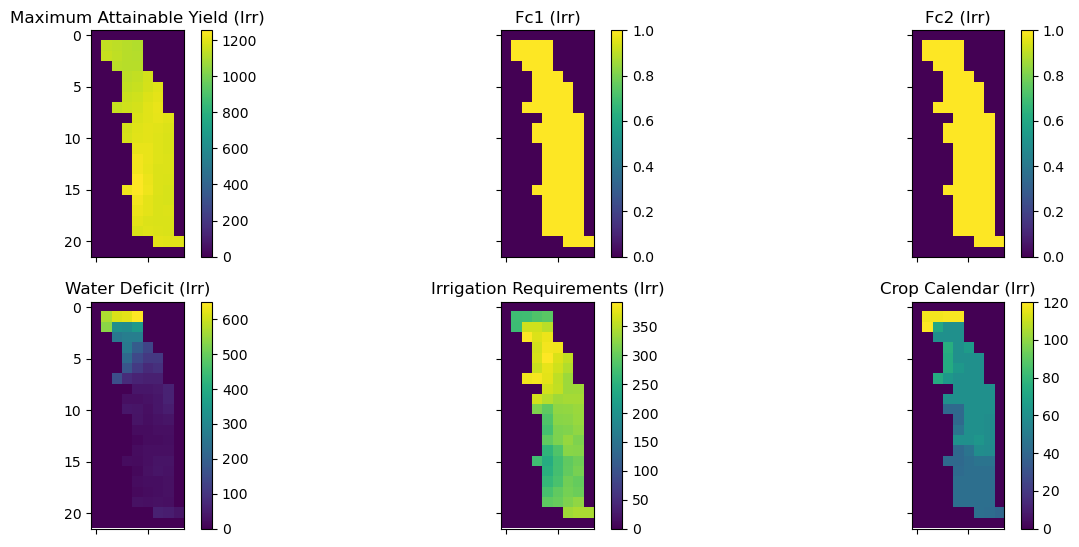

In [47]:
"""Plotting Module II Outputs"""
img_lst = [yld_irr, fc1_irr, fc2_irr, wde_irr, eta_irr, ccd_irr]
label_lst = ['Maximum Attainable Yield (Irr)', 'Fc1 (Irr)', 'Fc2 (Irr)', 'Water Deficit (Irr)',
             'Irrigation Requirements (Irr)', 'Crop Calendar (Irr)']

fig, ax = plt.subplots(3,3, sharex = True, sharey = True, figsize = (15,10))

val = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        if val < len(img_lst):
            img = ax[i,j].imshow(img_lst[val], vmax = np.nanmax(img_lst[val]), vmin = 0)
            plt.colorbar(img, ax = ax[i,j])
            ax[i,j].set_title(label_lst[val])
        else:
            ax[i,j].remove()
        val +=1
plt.show()

### Suitability Classes Determination based on Yield


Yield Classification
1.   not suitable (yields between 0% and 20%)
2.   marginally suitable (yields between 20% and 40%)
3.   moderately suitable (yields between 40% and 60%)
4. suitable (yields between 60% and 80%)
5. very suitable (yields are equivalent to 80% or more of the overall maximum yield)



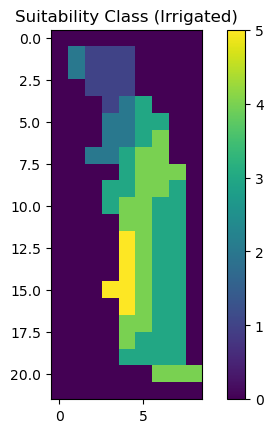

In [48]:
# get classified output of yield
yield_map_irr_class = classifyFinalYield(yld_irr)

'''visualize result'''

"""Classified Yield"""
plt.imshow(yield_map_irr_class, vmin = 0, vmax = 5)
plt.colorbar()
plt.title('Suitability Class (Irrigated)')
plt.show()

#### Saving Module II Irrigated Results

In [49]:
'''save result'''

# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_yld_irr.tif', yld_irr)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_fc1_irr.tif', fc1_irr)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_fc2_irr.tif', fc2_irr)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_wde_irr.tif', wde_irr)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_eta_irr.tif', eta_irr)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_ccd_irr.tif', ccd_irr)

saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_yld_irr_{YEAR}.tif', yld_irr)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_fc1_irr_{YEAR}.tif', fc1_irr)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_fc2_irr_{YEAR}.tif', fc2_irr)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_wde_irr_{YEAR}.tif', wde_irr)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_eta_irr_{YEAR}.tif', eta_irr)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_ccd_irr_{YEAR}.tif', ccd_irr)

##### Simulation for Rainfed Conditions

In [50]:
# '''run simulations'''
aez.simulateRainfedCropCycle(start_doy=1, end_doy=365, step_doy=1, leap_year=False)

EXECUTING coffee Rainfed Crop Simulation
-------------------------
Crop Type Perennial
-------------------------
Masking				=Activated
Thermal Climate Screening	=Activated
TSUM Screening			=Activated
Permafrost Screening		=Activated
Crop-specific Rule Screening	=Activated
-------------------------
Hibernation Principle		=Deactivated
-------------------------
Done:100.0 %
Rainfed Crop Simulation Completed


Simulation for Sugarcane

##### Outputs from Rainfed Crop Simulation
> Introducing new outputs
1. Crop-specific total water deficit (wde)
2. Crop-specific total irrigation requirements (eta)

In [51]:
yld_rain = aez.getEstimatedYieldRainfed() # Maximum attainable yield
fc1_rain = aez.getThermalReductionFactorRainfed() # Fc1 factor
fc2_rain = aez.getMoistureReductionFactorRainfed() # Fc2 factor
wde_rain = aez.getWDERainfed() # total water deficit
eta_rain = aez.getETARainfed() # total irrigation requirements 
ccd_rain = aez.getOptimumCycleStartDateRainfed() # crop calendar

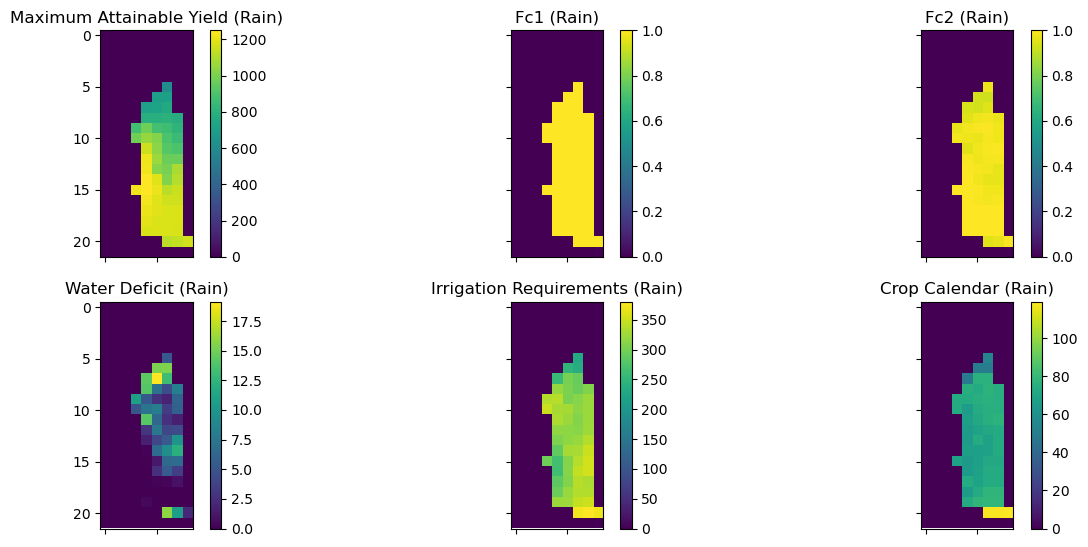

In [52]:
"""Plotting Module II Outputs"""
img_lst = [yld_rain, fc1_rain, fc2_rain, wde_rain, eta_rain, ccd_rain]
label_lst = ['Maximum Attainable Yield (Rain)', 'Fc1 (Rain)', 'Fc2 (Rain)', 'Water Deficit (Rain)',
             'Irrigation Requirements (Rain)', 'Crop Calendar (Rain)']

fig, ax = plt.subplots(3,3, sharex = True, sharey = True, figsize = (15,10))

val = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        if val < len(img_lst):
            img = ax[i,j].imshow(img_lst[val], vmax = np.nanmax(img_lst[val]), vmin = 0)
            plt.colorbar(img, ax = ax[i,j])
            ax[i,j].set_title(label_lst[val])
        else:
            ax[i,j].remove()
        val +=1
plt.show()

### Suitability Classes Determination based on Yield


Yield Classification
1.   not suitable (yields between 0% and 20%)
2.   marginally suitable (yields between 20% and 40%)
3.   moderately suitable (yields between 40% and 60%)
4. suitable (yields between 60% and 80%)
5. very suitable (yields are equivalent to 80% or more of the overall maximum yield)



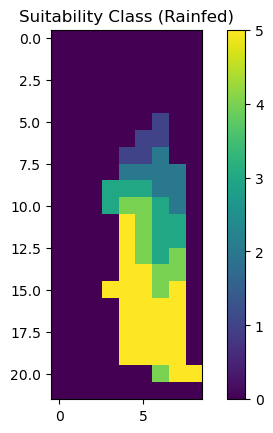

In [53]:
# get classified output of yield
yield_map_rain_class = classifyFinalYield(yld_rain)

'''visualize result'''

"""Classified Yield"""
plt.imshow(yield_map_rain_class, vmin = 0, vmax = 5)
plt.colorbar()
plt.title('Suitability Class (Rainfed)')
plt.show()

#### Saving Module II Rainfed Results

In [54]:
'''save result'''

# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_yld_rain.tif', yld_rain)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_fc1_rain.tif', fc1_rain)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_fc2_rain.tif', fc2_rain)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_wde_rain.tif', wde_rain)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_eta_rain.tif', eta_rain)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_ccd_rain.tif', ccd_rain)

saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_yld_rain_{YEAR}.tif', yld_rain)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_fc1_rain_{YEAR}.tif', fc1_rain)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_fc2_rain_{YEAR}.tif', fc2_rain)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_wde_rain_{YEAR}.tif', wde_rain)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_eta_rain_{YEAR}.tif', eta_rain)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_ccd_rain_{YEAR}.tif', ccd_rain)

<hr>

### END OF MODULE 2: CROP SIMULATION

<hr>